In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_1_CLL/notebooks/Post-hoc_Analysis


In [2]:
# Libraries
import numpy as np
import re
import pandas as pd
from sklearn.preprocessing import KBinsDiscretizer
import networkx as nx
from adjustText import adjust_text

import gc
import re
import random
import math

import stringdb
import string
import logging

import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.colors import Normalize, LinearSegmentedColormap

import igraph as ig
import leidenalg

In [3]:
gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_go = pd.read_excel("../../PASNet/Output/GO/sc1_weights.xlsx", index_col=0)
pt = pd.read_excel("../../PASNet/Input/GO/pt_fixed.xlsx", index_col=0)

sc1_go.columns = pt.columns
sc1_go.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_go.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_go = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_go = df_go[df_go['Weight'] != 0]

gc.collect()

# Biological priors with learning weights after supervised clustering
sc1_rest = pd.read_excel("../../PASNet/Output/REST/sc1_weights.xlsx", index_col=0)
pt = pd.read_excel("../../PASNet/Input/REST/pt_fixed.xlsx", index_col=0)

sc1_rest.columns = pt.columns
sc1_rest.index = pt.index

### data pre-processing to obtain the actual sc1_weights
data = []
for pathway, series in sc1_rest.iterrows():
    for gene, value in series.items():
        data.append([pathway, gene, value])

# PASNet outputs (source:pathway; target:protein; Weight:learning weights from PASNet)
df_rest = pd.DataFrame(data, columns=['source', 'target', 'Weight'])
df_rest = df_rest[df_rest['Weight'] != 0]

In [4]:
pasnet_genes_go = df_go['target'].unique()
print(len(pasnet_genes_go))

pasnet_genes_rest = df_rest['target'].unique()
print(len(pasnet_genes_rest))

297
269


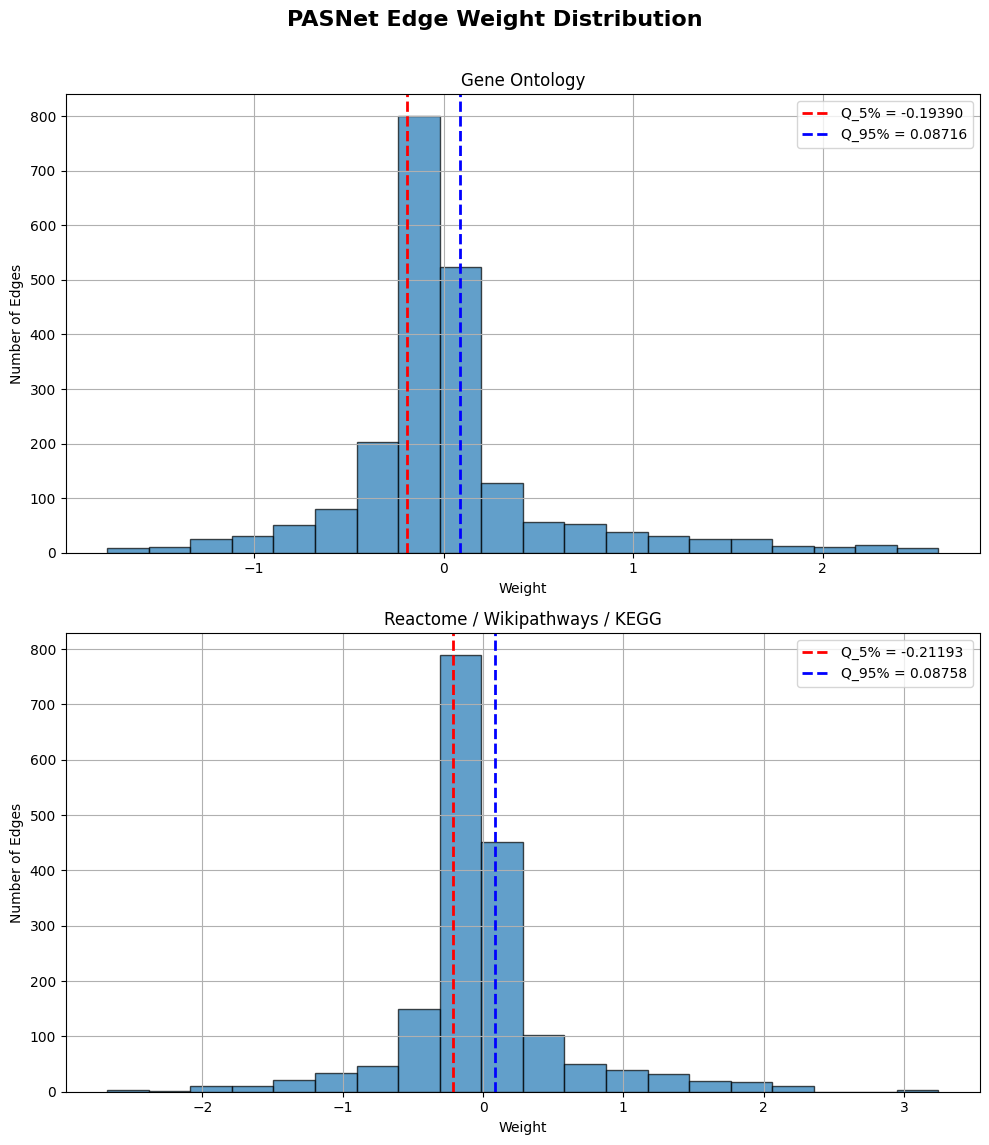

In [5]:
import matplotlib.pyplot as plt

# Gene Ontology weights
weight_go = df_go['Weight']
q1_go = weight_go.quantile(0.25)
q3_go = weight_go.quantile(0.75)

# Reactome/Wikipathways/KEGG weights
weight_rest = df_rest['Weight']
q1_rest = weight_rest.quantile(0.25)
q3_rest = weight_rest.quantile(0.75)

# Create 2x1 subplot (stacked vertically)
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=False)

# Add overall figure title (multipanel title)
fig.suptitle('PASNet Edge Weight Distribution', fontsize=16, fontweight='bold', y=0.95)

# Plot Gene Ontology histogram
axes[0].hist(weight_go, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(x=q1_go, color='red', linestyle='--', linewidth=2, label=f'Q_5% = {q1_go:.5f}')
axes[0].axvline(x=q3_go, color='blue', linestyle='--', linewidth=2, label=f'Q_95% = {q3_go:.5f}')
axes[0].set_title('Gene Ontology')
axes[0].set_xlabel('Weight')
axes[0].set_ylabel('Number of Edges')
axes[0].grid(True)
axes[0].legend()

# Plot Reactome/Wikipathways/KEGG histogram
axes[1].hist(weight_rest, bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(x=q1_rest, color='red', linestyle='--', linewidth=2, label=f'Q_5% = {q1_rest:.5f}')
axes[1].axvline(x=q3_rest, color='blue', linestyle='--', linewidth=2, label=f'Q_95% = {q3_rest:.5f}')
axes[1].set_title('Reactome / Wikipathways / KEGG')
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Number of Edges')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space for suptitle
plt.savefig('../../figures/edge_weight_distribution.png', dpi=300)  # Save as high-res PNG
plt.show()


In [6]:
df_go = df_go[(df_go['Weight'] > q3_go) | (df_go['Weight'] < q1_go)]
df_rest = df_rest[(df_rest['Weight'] > q3_rest) | (df_rest['Weight'] < q1_rest)]

In [7]:
shap_validation = pd.read_csv("../../PASNet/Output/GO/feature_importance_table_icgc_validation.csv", index_col=0)
shap_validation_top20 = shap_validation.sort_values(by="Importance", ascending=False).head(20)

shap_testing = pd.read_csv("../../PASNet/Output/GO/feature_importance_table_bcmo_testing.csv", index_col=0)
shap_testing_top20 = shap_testing.sort_values(by="Importance", ascending=False).head(20)

combined_df = pd.concat([shap_validation_top20, shap_testing_top20], axis=0)
combined_df = combined_df.sort_values(by="Importance", ascending=False)
combined_df_go = combined_df[~combined_df.index.duplicated(keep='first')]

shap_validation = pd.read_csv("../../PASNet/Output/REST/feature_importance_table_icgc_validation.csv", index_col=0)
shap_validation_top20 = shap_validation.sort_values(by="Importance", ascending=False).head(20)

shap_testing = pd.read_csv("../../PASNet/Output/REST/feature_importance_table_bcmo_testing.csv", index_col=0)
shap_testing_top20 = shap_testing.sort_values(by="Importance", ascending=False).head(20)

combined_df = pd.concat([shap_validation_top20, shap_testing_top20], axis=0)
combined_df = combined_df.sort_values(by="Importance", ascending=False)
combined_df_rest = combined_df[~combined_df.index.duplicated(keep='first')]

In [8]:
# Step 1: Get the feature names (index) from both DataFrames
features_rest = combined_df_rest.index
features_go = combined_df_go.index

# Step 2: Combine the feature names
combined_features = features_rest.to_list() + features_go.to_list()

# Step 3: Remove duplicates
unique_features = pd.Index(combined_features).unique()

# Optional: Convert to DataFrame if needed
features_df = pd.DataFrame(unique_features, columns=['Feature'])

In [9]:
# Assuming your DataFrame is called df
table_go = df_go.pivot_table(
    index='source',      # rows
    columns='target',    # columns
    values='Weight',     # values to fill
    fill_value=0         # fill missing with 0
)

# Optional: reset column names if needed
table_go = table_go.reset_index()

# Assuming your DataFrame is called df
table_rest = df_rest.pivot_table(
    index='source',      # rows
    columns='target',    # columns
    values='Weight',     # values to fill
    fill_value=0         # fill missing with 0
)

# Optional: reset column names if needed
table_rest = table_rest.reset_index()

In [10]:
def filter_table(table, features_df):
    # Set 'source' as index if not already
    table_indexed = table.set_index('source')
    
    # Keep only columns present in features_df['Feature']
    filtered_table = table_indexed[table_indexed.columns.intersection(features_df['Feature'])]
    
    # Keep only rows where the sum across columns is not 0
    filtered_table = filtered_table[filtered_table.sum(axis=1) != 0]
    
    # Reset index to bring 'source' back as a column
    return filtered_table.reset_index()

# Apply the function to both tables
filtered_table_go = filter_table(table_go, features_df)
filtered_table_rest = filter_table(table_rest, features_df)

In [11]:
#clustered_rest['source'].to_list()

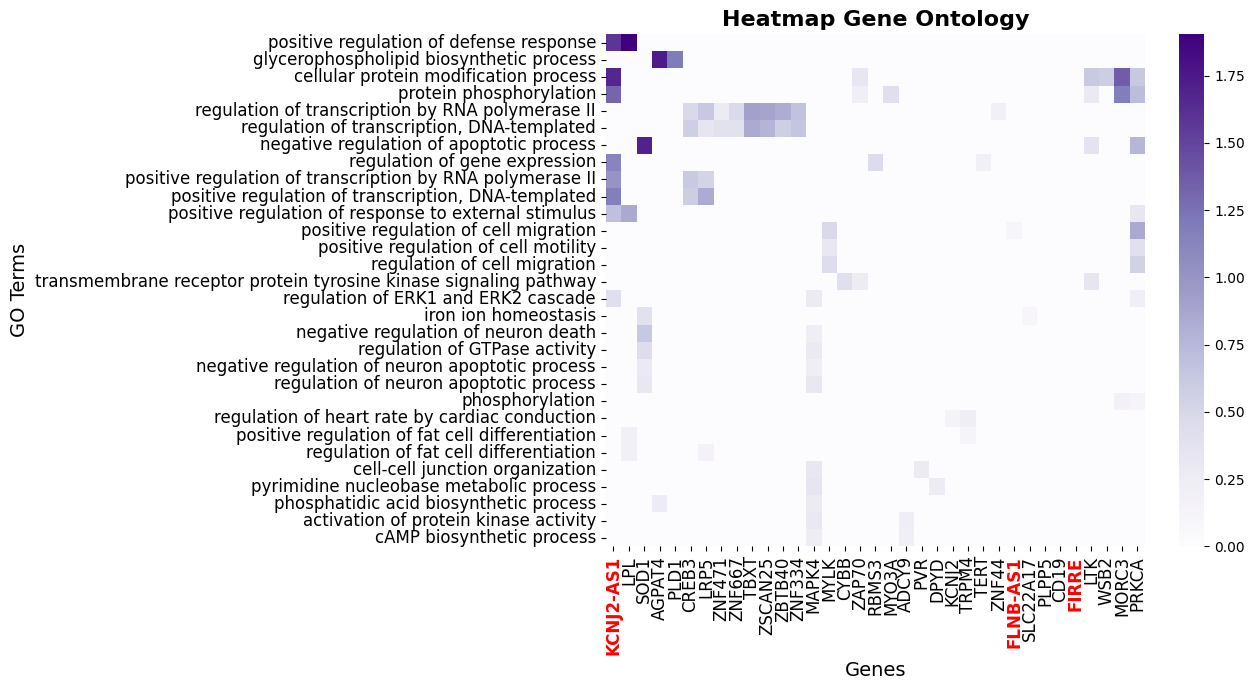

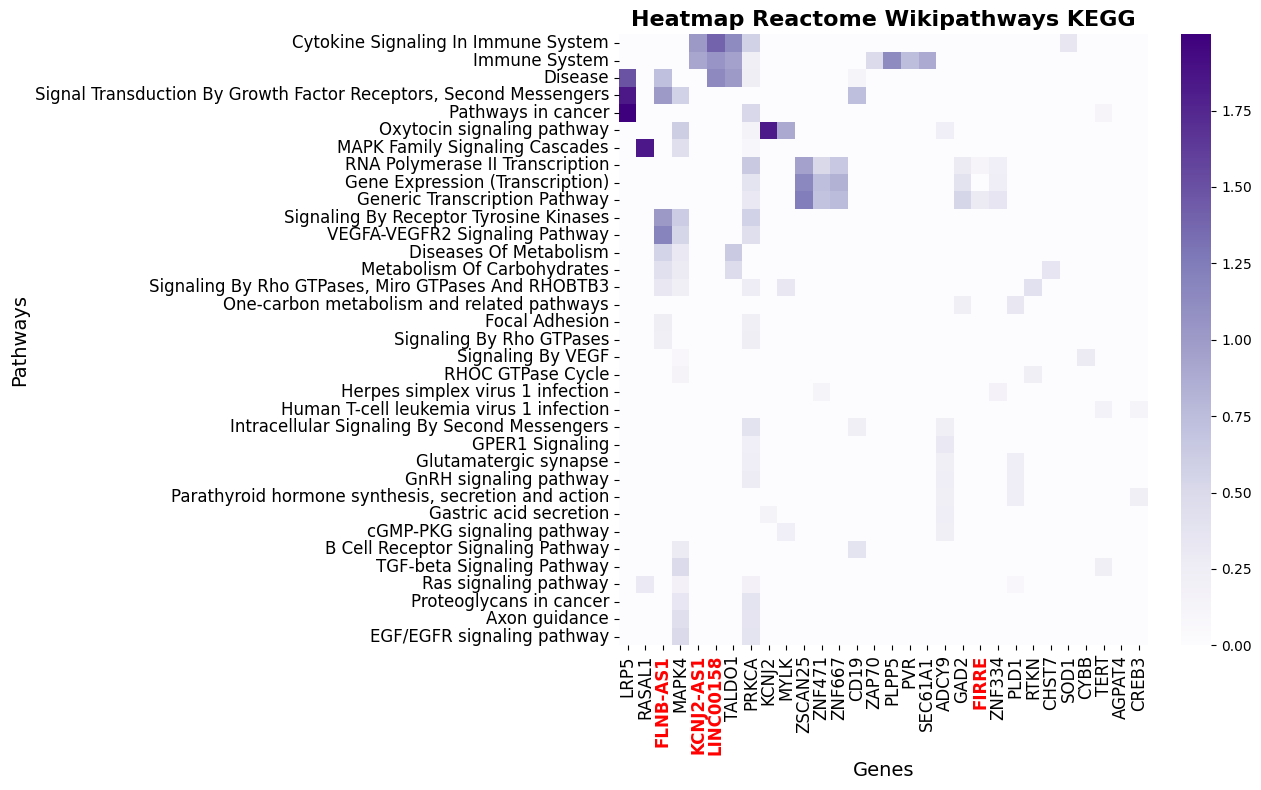

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.cluster.hierarchy import linkage, leaves_list

# Example test genes
test_genes = ["FIRRE", "MIR4458HG", "LINC00158", "KCNJ2-AS1", "FLNB-AS1"]

# Take absolute values
abs_table_go = filtered_table_go.copy()
abs_table_go.iloc[:, 1:] = abs_table_go.iloc[:, 1:].abs()  # skip 'source' column

abs_table_rest = filtered_table_rest.copy()
abs_table_rest.iloc[:, 1:] = abs_table_rest.iloc[:, 1:].abs()  # skip 'source' column

# 🔹 Filter rows with at least 2 non-zero values
abs_table_go = abs_table_go[abs_table_go.iloc[:, 1:].gt(0).sum(axis=1) >= 2]
abs_table_rest = abs_table_rest[abs_table_rest.iloc[:, 1:].gt(0).sum(axis=1) >= 2]

# Function to reorder dataframe by hierarchical clustering
def cluster_dataframe(df):
    data = df.iloc[:, 1:]  # numeric part only
    row_linkage = linkage(data, method='average', metric='euclidean')
    col_linkage = linkage(data.T, method='average', metric='euclidean')
    row_order = leaves_list(row_linkage)
    col_order = leaves_list(col_linkage)
    clustered_df = df.iloc[row_order, :]
    clustered_df = clustered_df.iloc[:, [0] + (col_order + 1).tolist()]
    return clustered_df

# Cluster both filtered tables
clustered_go = cluster_dataframe(abs_table_go)
clustered_rest = cluster_dataframe(abs_table_rest)

# 🔹 Clean source names
def clean_source_names(df):
    df = df.copy()
    # Remove (GO:xxxx)
    df['source'] = df['source'].str.replace(r"\s*\(GO:[^)]+\)", "", regex=True)
    # Remove trailing R-HSAxxxx
    df['source'] = df['source'].str.replace(r"\s*R-HSA-\d+$", "", regex=True)
    # Remove trailing WPxxxx
    df['source'] = df['source'].str.replace(r"\s*WP\d+$", "", regex=True)
    return df

clustered_go = clean_source_names(clustered_go)
clustered_rest = clean_source_names(clustered_rest)

# Shorten a specific pathway name
clustered_rest['source'] = clustered_rest['source'].replace(
    "Diseases Of Signal Transduction By Growth Factor Receptors And Second Messengers",
    "Signal Transduction By Growth Factor Receptors, Second Messengers"
)

# Function to color bold test genes on x-axis
def color_xticklabels(ax, test_genes):
    for tick in ax.get_xticklabels():
        if tick.get_text() in test_genes:
            tick.set_color('red')
            tick.set_fontweight('bold')
        else:
            tick.set_color('black')
            tick.set_fontweight('normal')
    ax.tick_params(axis='x', rotation=90)

# --- Heatmap for GO table ---
fig1, ax1 = plt.subplots(figsize=(13, 7))
sns.heatmap(
    clustered_go.set_index('source'),
    ax=ax1,
    cmap='Purples',
    annot=False,
    yticklabels=True
)
ax1.set_title('Heatmap Gene Ontology', fontsize=16, fontweight='bold')
ax1.set_xlabel('Genes', fontsize=14)
ax1.set_ylabel('GO Terms', fontsize=14)
ax1.tick_params(axis='x', labelsize=12, rotation=90)
ax1.tick_params(axis='y', labelsize=12)
color_xticklabels(ax1, test_genes)

plt.tight_layout()
plt.savefig("../../figures/hierarchical_weights_heatmap_GO.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Heatmap for Rest table ---
fig2, ax2 = plt.subplots(figsize=(13, 8))
sns.heatmap(
    clustered_rest.set_index('source'),
    ax=ax2,
    cmap='Purples',
    annot=False,
    yticklabels=True
)
ax2.set_title('Heatmap Reactome Wikipathways KEGG', fontsize=16, fontweight='bold')
ax2.set_xlabel('Genes', fontsize=14)
ax2.set_ylabel('Pathways', fontsize=14)
ax2.tick_params(axis='x', labelsize=12, rotation=90)
ax2.tick_params(axis='y', labelsize=12)
color_xticklabels(ax2, test_genes)

plt.tight_layout()
plt.savefig("../../figures/hierarchical_weights_heatmap_rest.png", dpi=300, bbox_inches='tight')
plt.show()


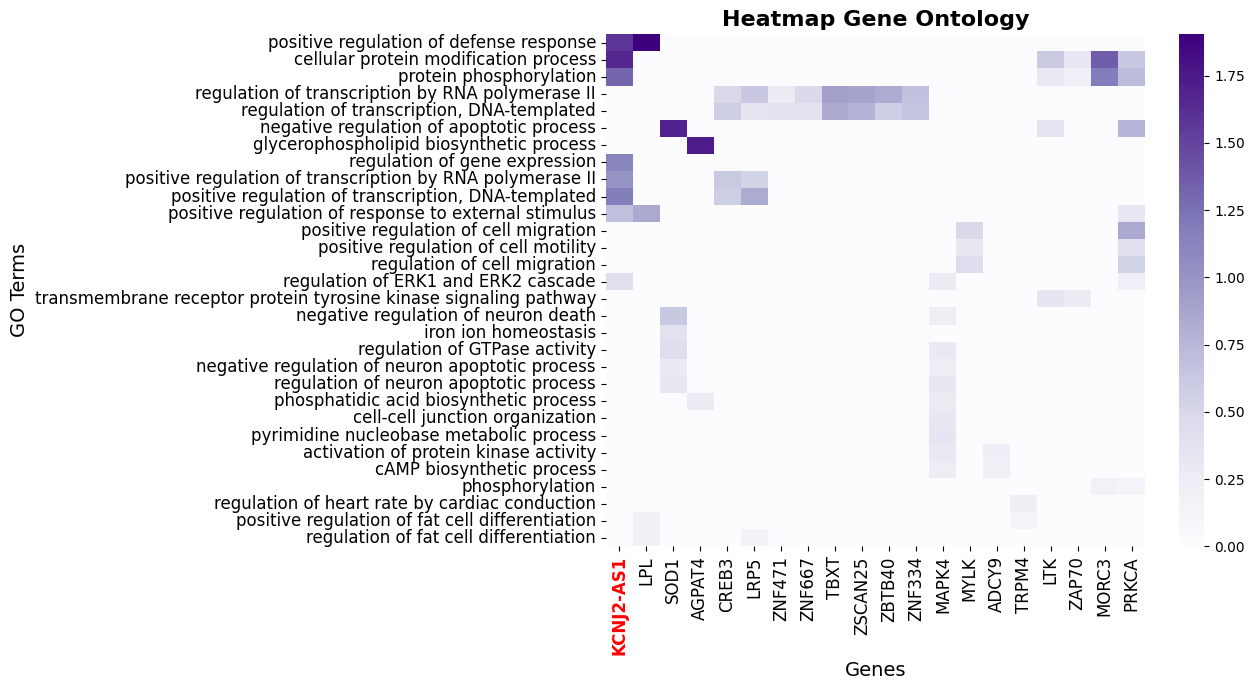

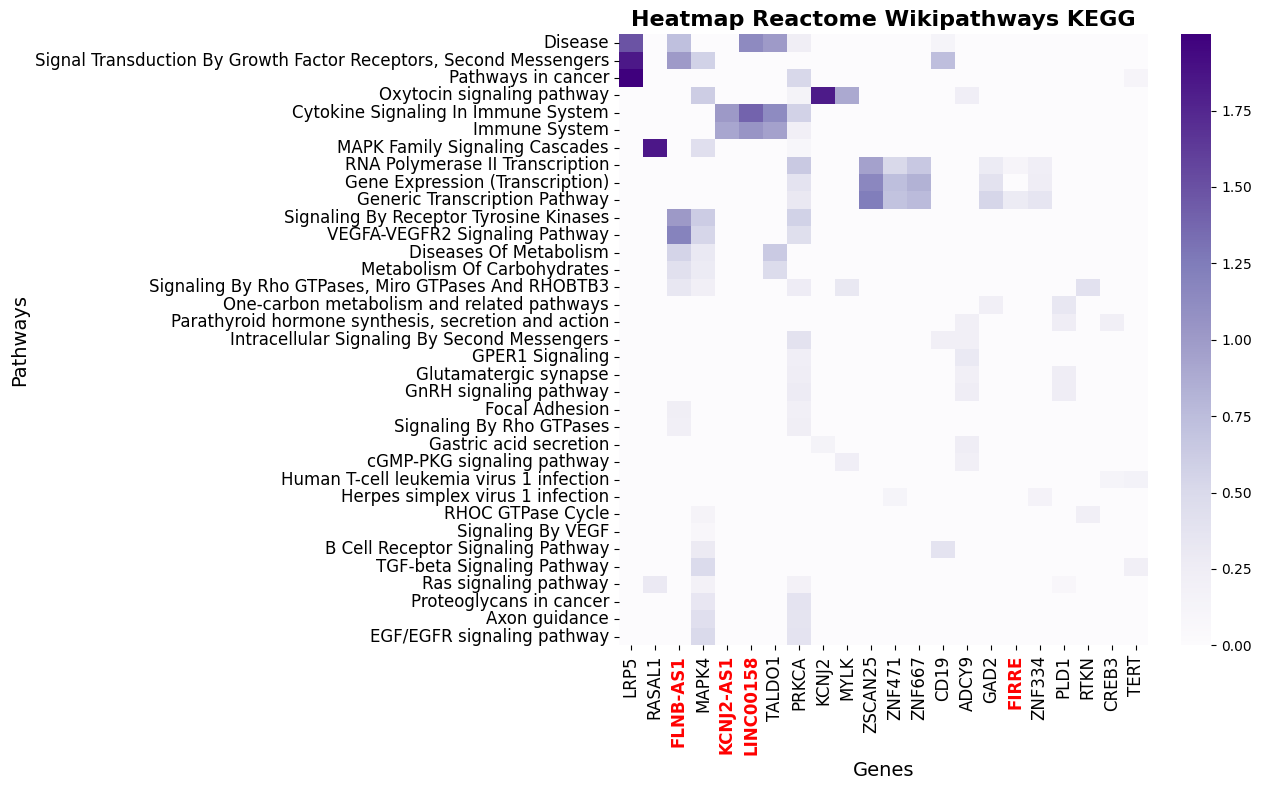

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.cluster.hierarchy import linkage, leaves_list

# Example test genes
test_genes = ["FIRRE", "MIR4458HG", "LINC00158", "KCNJ2-AS1", "FLNB-AS1"]

# Take absolute values
abs_table_go = filtered_table_go.copy()
abs_table_go.iloc[:, 1:] = abs_table_go.iloc[:, 1:].abs()  # skip 'source' column

abs_table_rest = filtered_table_rest.copy()
abs_table_rest.iloc[:, 1:] = abs_table_rest.iloc[:, 1:].abs()  # skip 'source' column

# 🔹 Filter rows and columns with at least 2 non-zero values
def filter_rows_cols(df, min_nonzero=2):
    df = df.copy()
    # Filter rows: at least `min_nonzero` non-zero values across genes
    df = df[df.iloc[:, 1:].gt(0).sum(axis=1) >= min_nonzero]
    # Filter columns: keep gene columns with at least `min_nonzero` non-zero values across rows
    nonzero_genes = df.iloc[:, 1:].gt(0).sum(axis=0) >= min_nonzero
    # Keep 'source' column + filtered gene columns
    df = pd.concat([df[['source']], df.iloc[:, 1:].loc[:, nonzero_genes]], axis=1)
    return df

abs_table_go = filter_rows_cols(abs_table_go, min_nonzero=2)
abs_table_rest = filter_rows_cols(abs_table_rest, min_nonzero=2)

# Function to reorder dataframe by hierarchical clustering
def cluster_dataframe(df):
    data = df.iloc[:, 1:]  # numeric part only
    row_linkage = linkage(data, method='average', metric='euclidean')
    col_linkage = linkage(data.T, method='average', metric='euclidean')
    row_order = leaves_list(row_linkage)
    col_order = leaves_list(col_linkage)
    clustered_df = df.iloc[row_order, :]
    clustered_df = clustered_df.iloc[:, [0] + (col_order + 1).tolist()]
    return clustered_df

# Cluster both filtered tables
clustered_go = cluster_dataframe(abs_table_go)
clustered_rest = cluster_dataframe(abs_table_rest)

# 🔹 Clean source names
def clean_source_names(df):
    df = df.copy()
    # Remove (GO:xxxx)
    df['source'] = df['source'].str.replace(r"\s*\(GO:[^)]+\)", "", regex=True)
    # Remove trailing R-HSAxxxx
    df['source'] = df['source'].str.replace(r"\s*R-HSA-\d+$", "", regex=True)
    # Remove trailing WPxxxx
    df['source'] = df['source'].str.replace(r"\s*WP\d+$", "", regex=True)
    return df

clustered_go = clean_source_names(clustered_go)
clustered_rest = clean_source_names(clustered_rest)

# Shorten a specific pathway name
clustered_rest['source'] = clustered_rest['source'].replace(
    "Diseases Of Signal Transduction By Growth Factor Receptors And Second Messengers",
    "Signal Transduction By Growth Factor Receptors, Second Messengers"
)

# Function to color bold test genes on x-axis
def color_xticklabels(ax, test_genes):
    for tick in ax.get_xticklabels():
        if tick.get_text() in test_genes:
            tick.set_color('red')
            tick.set_fontweight('bold')
        else:
            tick.set_color('black')
            tick.set_fontweight('normal')
    ax.tick_params(axis='x', rotation=90)

# --- Heatmap for GO table ---
fig1, ax1 = plt.subplots(figsize=(13, 7))
sns.heatmap(
    clustered_go.set_index('source'),
    ax=ax1,
    cmap='Purples',
    annot=False,
    yticklabels=True
)
ax1.set_title('Heatmap Gene Ontology', fontsize=16, fontweight='bold')
ax1.set_xlabel('Genes', fontsize=14)
ax1.set_ylabel('GO Terms', fontsize=14)
ax1.tick_params(axis='x', labelsize=12, rotation=90)
ax1.tick_params(axis='y', labelsize=12)
color_xticklabels(ax1, test_genes)

plt.tight_layout()
plt.savefig("../../figures/hierarchical_weights_heatmap_GO.png", dpi=300, bbox_inches='tight')
plt.show()

# --- Heatmap for Rest table ---
fig2, ax2 = plt.subplots(figsize=(13, 8))
sns.heatmap(
    clustered_rest.set_index('source'),
    ax=ax2,
    cmap='Purples',
    annot=False,
    yticklabels=True
)
ax2.set_title('Heatmap Reactome Wikipathways KEGG', fontsize=16, fontweight='bold')
ax2.set_xlabel('Genes', fontsize=14)
ax2.set_ylabel('Pathways', fontsize=14)
ax2.tick_params(axis='x', labelsize=12, rotation=90)
ax2.tick_params(axis='y', labelsize=12)
color_xticklabels(ax2, test_genes)

plt.tight_layout()
plt.savefig("../../figures/hierarchical_weights_heatmap_rest.png", dpi=300, bbox_inches='tight')
plt.show()


In [12]:
# Extract pathway names (row labels) from clustered dataframes
go_pathways = clustered_go['source'].tolist()
rest_pathways = clustered_rest['source'].tolist()

# Optional: save to CSV for downstream use
pd.DataFrame({'GO_Pathways': go_pathways}).to_csv('clustered_go_pathways.csv', index=False)
pd.DataFrame({'Rest_Pathways': rest_pathways}).to_csv('clustered_rest_pathways.csv', index=False)

# Print to check
#print("GO pathways:")
#print(go_pathways)

#print("\nRest pathways:")
#print(rest_pathways)

In [ ]:
### NETWORK

In [13]:
df_go['MI'] = None
df_go['spearman'] = None
df_go['p-value'] = None

df_rest['MI'] = None
df_rest['spearman'] = None
df_rest['p-value'] = None

In [14]:
combined_df = pd.concat([df_go, df_rest], axis=0, ignore_index=True)

#Harmonizing with the SJARACNe file format that is to follow
genes_list = pd.concat([combined_df['source'], combined_df['target']]).unique().tolist()

combined_df['MI'] = None
combined_df['spearman'] = None
combined_df['p-value'] = None

In [15]:
res_icgc = pd.read_excel("../../results/ICGC/ICGC_NetBID2_ms_tab.xlsx")
res_icgc = res_icgc[['originalID', 'funcType', 'Size', 'logFC.U.Vs.M_DA', 'adj.P.Val.U.Vs.M_DA', 'Z.U.Vs.M_DA', 'logFC.U.Vs.M_DE', 'adj.P.Val.U.Vs.M_DE', 'Z.U.Vs.M_DE']]
res_icgc.rename(columns={
    'originalID': 'ID',
    'funcType': 'Type',
    'logFC.U.Vs.M_DA': 'logFC_DA',
    'adj.P.Val.U.Vs.M_DA': 'adj.P.Val_DA',
    'Z.U.Vs.M_DA': 'Z-score_DA',
    'logFC.U.Vs.M_DE': 'logFC_DE',
    'adj.P.Val.U.Vs.M_DE': 'adj.P.Val_DE',
    'Z.U.Vs.M_DE': 'Z-score_DE',
}, inplace=True)

# Create a temporary column to give priority to "TF" rows
res_icgc['priority'] = res_icgc['Type'].apply(lambda x: 0 if x == 'TF' else 1)

# Sort the DataFrame by the 'priority' column (TF first) and by ID to make sure we keep the first occurrence
res_icgc = res_icgc.sort_values(by=['priority', 'ID'])

# Remove duplicated rows by 'ID', keeping the first occurrence (which should be the "TF" if it's present)
res_icgc = res_icgc.drop_duplicates(subset='ID', keep='first')

res_icgc = res_icgc.drop(columns=['priority'])

res_icgc_filt_overt = res_icgc[
    (res_icgc['adj.P.Val_DA'] < 0.05) &
    (res_icgc['adj.P.Val_DE'] < 0.05) &
    (res_icgc['Size'] > 30)
]

res_icgc_filt_hidden = res_icgc[
    (res_icgc['adj.P.Val_DA'] < 0.05) &
    (res_icgc['adj.P.Val_DE'] > 0.05) &
    (res_icgc['Size'] > 30)
]

print("Overt Drivers:", len(res_icgc_filt_overt), "\n"
      "Hidden_Drivers:", len(res_icgc_filt_hidden), "\n"
      "Overt TFs:", len(res_icgc_filt_overt[res_icgc_filt_overt['Type'] == "TF"]), "\n"
      "Overt SIGs:", len(res_icgc_filt_overt[res_icgc_filt_overt['Type'] == "SIG"]), "\n"
      "Overt NCs:", len(res_icgc_filt_overt[res_icgc_filt_overt['Type'] == "NC"]), "\n"
      "Hidden TFs:", len(res_icgc_filt_hidden[res_icgc_filt_hidden['Type'] == "TF"]), "\n"
      "Hidden SIGs:", len(res_icgc_filt_hidden[res_icgc_filt_hidden['Type'] == "SIG"]), "\n"
      "Hidden NCs:", len(res_icgc_filt_hidden[res_icgc_filt_hidden['Type'] == "NC"]))

Overt Drivers: 793 
Hidden_Drivers: 1070 
Overt TFs: 185 
Overt SIGs: 293 
Overt NCs: 315 
Hidden TFs: 273 
Hidden SIGs: 400 
Hidden NCs: 397


In [16]:
res_icgc_filt = res_icgc[res_icgc['ID'].isin(features_df['Feature'])]
len(res_icgc_filt)

49

In [17]:
df_sj_sig = pd.read_csv("../../results/ICGC/SJARACNe_networks/output_sig_sjaracne_ICGC_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_tf = pd.read_csv("../../results/ICGC/SJARACNe_networks/output_tf_sjaracne_ICGC_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')
df_sj_nc = pd.read_csv("../../results/ICGC/SJARACNe_networks/output_nc_sjaracne_ICGC_NetBID2_out_.final/consensus_network_ncol_.txt", sep='\t')

# Row binding the two dataframes
df_sj = pd.concat([df_sj_sig, df_sj_tf, df_sj_nc], axis=0, ignore_index=True)

# Removing duplicates based on columns "source" and "target"
df_sj = df_sj.drop_duplicates(subset=['source', 'target'])

# Keep only the specified columns: source, label, MI, spearman, p-value
columns_to_keep = ['source', 'target', 'MI', 'spearman', 'p-value']
df_sj = df_sj[columns_to_keep]

#Harmonizing with PASNet outputs
df_sj['Weight'] = None
df_sj = df_sj[df_sj['p-value'] <= 0.05]

df_sj['sorted_pair'] = df_sj.apply(lambda row: tuple(sorted([row['source'], row['target']])), axis=1)
df_sj = df_sj.sort_values(by='MI', ascending=False).drop_duplicates(subset=['sorted_pair']).drop(columns=['sorted_pair'])

df_go = pd.concat([df_go, df_sj], ignore_index=True)
df_rest = pd.concat([df_rest, df_sj], ignore_index=True)
print("Gene Ontology:", len(df_go), "\n"
      "Rest of databases:", len(df_rest))

/tmp/ipykernel_2444/788812461.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_go = pd.concat([df_go, df_sj], ignore_index=True)


Gene Ontology: 395898 
Rest of databases: 395728


/tmp/ipykernel_2444/788812461.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_rest = pd.concat([df_rest, df_sj], ignore_index=True)


In [18]:
import pandas as pd
import numpy as np

# Assuming df_go and df_rest already exist
# and go_pathways and rest_pathways are lists of pathways

# 1. Create weights_go_df
weights_go = df_go['source'].unique()
weights_go_df = pd.DataFrame({
    'ID': weights_go,
    'Type': "Pathway",
    'Size': np.nan,
    'logFC_DA': np.nan,
    'adj.P.Val_DA': np.nan,
    'Z-score_DA': np.nan,
    'logFC_DE': np.nan,
    'adj.P.Val_DE': np.nan,
    'Z-score_DE': np.nan
})

# Filter weights_go_df to keep only IDs that match go_pathways
weights_go_df_filtered = weights_go_df[
    weights_go_df['ID'].apply(lambda x: any(go in x for go in go_pathways))
]

# 2. Create weights_rest_df
weights_rest = df_rest['source'].unique()
weights_rest_df = pd.DataFrame({
    'ID': weights_rest,
    'Type': "Pathway",
    'Size': np.nan,
    'logFC_DA': np.nan,
    'adj.P.Val_DA': np.nan,
    'Z-score_DA': np.nan,
    'logFC_DE': np.nan,
    'adj.P.Val_DE': np.nan,
    'Z-score_DE': np.nan
})

# Filter weights_rest_df to keep only IDs that match rest_pathways
weights_rest_df_filtered = weights_rest_df[
    weights_rest_df['ID'].apply(lambda x: any(go in x for go in rest_pathways))
]

# 3. Concatenate with res_icgc_filt
node_combined_go = pd.concat([res_icgc_filt, weights_go_df_filtered], ignore_index=True)
node_combined_rest = pd.concat([res_icgc_filt, weights_rest_df_filtered], ignore_index=True)

# 4. Print lengths
print("Gene Ontology:", len(node_combined_go), "\n"
      "Rest of databases:", len(node_combined_rest))


Gene Ontology: 88 
Rest of databases: 88


In [19]:
# Step 1: Read the DataFrame with the edge connections
df_edges = df_go

# Step 2: Read the DataFrame with node attributes
df_node_attributes = node_combined_go

#df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) | df_edges['target'].isin(df_node_attributes['ID'])]
df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) & df_edges['target'].isin(df_node_attributes['ID'])]

# Step 3: Create a undirected graph
G = nx.Graph()

# Step 4: Add edges to the graph
for index, row in df_edges.iterrows():
    source = row['source']
    target = row['target']
    attributes = row.drop(['source', 'target'])  # Extract edge attributes
    G.add_edge(source, target, **attributes)  # Add edge with attributes

# Step 5: Transfer node attributes
for index, row in df_node_attributes.iterrows():
    node_name = row['ID']
    if node_name in G.nodes:
        attributes = row.drop('ID')  # Remove the node name to keep only the attributes
        G.nodes[node_name].update(attributes)

# Add a new attribute 'label' with node names
for node in G.nodes:
    G.nodes[node]['label'] = str(node)  # Set 'label' attribute to node name (convert to string if needed)

print(f"Edges: {len(G.edges)}")
print(f"Nodes: {len(G.nodes)}")

Edges: 290
Nodes: 82


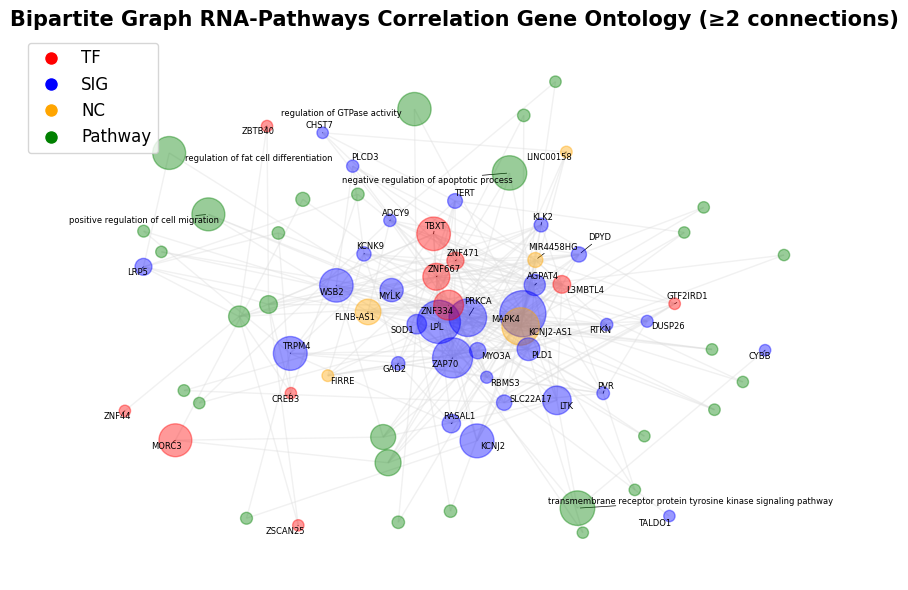

In [20]:
F = G

# Parameters
label_types = {'NC', 'TF', 'SIG'}
top_n_pathways = 5   # number of top pathways to label
min_degree_pathway = 2  # keep only pathways with >= 3 connections

# Clean labels function
def clean_label(label):
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# Keep only pathways with at least min_degree_pathway neighbors
pathways_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] == 'Pathway' and F.degree(n) >= min_degree_pathway
]

# Create subgraph with those pathways + all other node types
nodes_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] in label_types or n in pathways_to_keep
]
F_filtered = F.subgraph(nodes_to_keep).copy()

# Recompute centrality on filtered graph
centrality = nx.betweenness_centrality(F_filtered, k=10, endpoints=True)

# Compute pathway correlation (using centrality as proxy)
pathway_corr = {n: centrality[n] for n in F_filtered.nodes() if F_filtered.nodes[n]['Type'] == 'Pathway'}

# Select top N pathways
top_pathways = sorted(pathway_corr, key=pathway_corr.get, reverse=True)[:top_n_pathways]

# Create label dictionary: NC, TF, SIG + top pathways
cleaned_labels = {}
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in label_types or node in top_pathways:
        cleaned_labels[node] = clean_label(node)

# Compute positions, colors, and node sizes
pos = nx.spring_layout(F_filtered, k=0.8, seed=1400)
type_color_map = {'TF': 'red', 'SIG': 'blue', 'NC': 'orange', 'Pathway': 'green'}
node_color = [type_color_map.get(F_filtered.nodes[node]['Type'], 'grey') for node in F_filtered.nodes()]
node_size = [centrality[v] * 5000 for v in F_filtered.nodes()]

# Plot graph
fig, ax = plt.subplots(figsize=(9, 6))

nx.draw_networkx_nodes(F_filtered, pos=pos, node_color=node_color, node_size=node_size, alpha=0.4)
nx.draw_networkx_edges(F_filtered, pos=pos, edge_color="gainsboro", alpha=0.4)

# Add labels
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    text = ax.text(x, y, label, fontsize=6, ha='center', va='center')
    texts.append(text)

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
           for color in type_color_map.values()]
labels = list(type_color_map.keys())
ax.legend(handles=handles, labels=labels, loc='upper left', fontsize=12)

plt.title("Bipartite Graph RNA-Pathways Correlation Gene Ontology (≥2 connections)", fontsize=15, fontweight='bold')
ax.margins(0.1, 0.05)
fig.tight_layout()
plt.axis("off")
plt.savefig("../../figures/Bipartite_graph_CLL_filtered_GO.png", dpi=300, bbox_inches='tight')
plt.show()

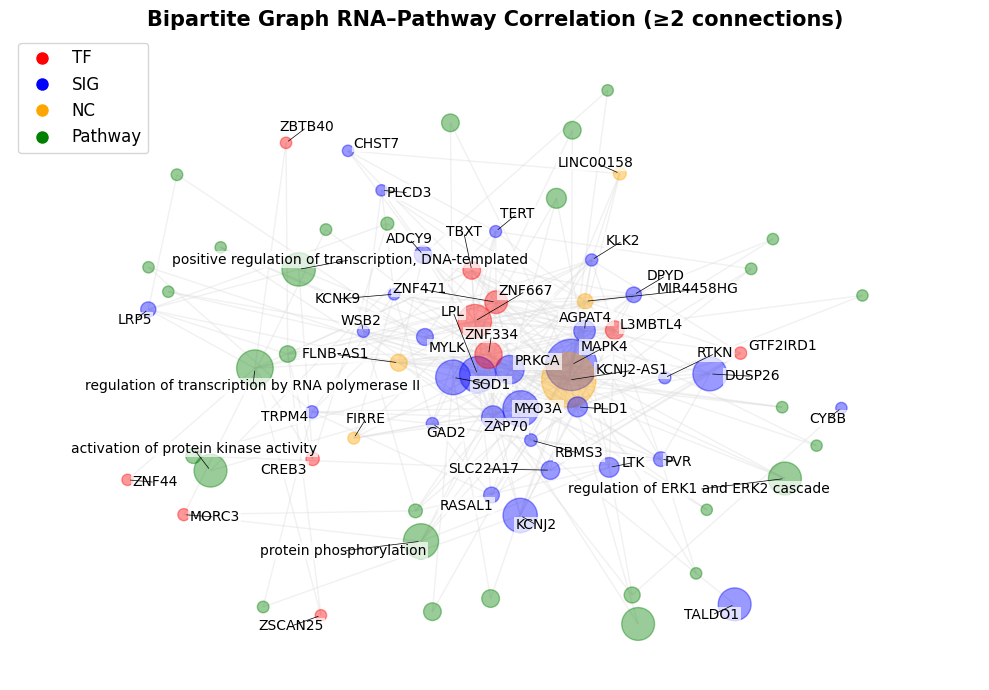

In [22]:
import re
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text

# --- PARAMETERS ---
F = G  # assuming G is already defined elsewhere

label_types = {'NC', 'TF', 'SIG'}
top_n_pathways = 5       # number of top pathways to label
min_degree_pathway = 2   # keep only pathways with >= 2 connections

# --- FUNCTIONS ---
def clean_label(label):
    """Remove pathway IDs or GO terms from label names for clarity."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# --- FILTER PATHWAYS BY DEGREE ---
pathways_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] == 'Pathway' and F.degree(n) >= min_degree_pathway
]

# --- KEEP RELEVANT NODES (TF, SIG, NC + selected pathways) ---
nodes_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] in label_types or n in pathways_to_keep
]
F_filtered = F.subgraph(nodes_to_keep).copy()

# --- COMPUTE CENTRALITY ---
centrality = nx.betweenness_centrality(F_filtered, k=10, endpoints=True)

# --- SELECT TOP N PATHWAYS BY CENTRALITY ---
pathway_corr = {n: centrality[n] for n in F_filtered.nodes() if F_filtered.nodes[n]['Type'] == 'Pathway'}
top_pathways = sorted(pathway_corr, key=pathway_corr.get, reverse=True)[:top_n_pathways]

# --- CLEAN LABELS (TF, SIG, NC + TOP PATHWAYS) ---
cleaned_labels = {}
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in label_types or node in top_pathways:
        cleaned_labels[node] = clean_label(node)

# --- VISUALIZATION ---
pos = nx.spring_layout(F_filtered, k=0.8, seed=1400)

type_color_map = {'TF': 'red', 'SIG': 'blue', 'NC': 'orange', 'Pathway': 'green'}
node_color = [type_color_map.get(F_filtered.nodes[node]['Type'], 'grey') for node in F_filtered.nodes()]
node_size = [centrality[v] * 5000 for v in F_filtered.nodes()]

# --- PLOT GRAPH ---
fig, ax = plt.subplots(figsize=(10, 7))

nx.draw_networkx_nodes(F_filtered, pos=pos, node_color=node_color, node_size=node_size, alpha=0.4)
nx.draw_networkx_edges(F_filtered, pos=pos, edge_color="gainsboro", alpha=0.4)

# --- ADD LABELS ---
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    text = ax.text(
        x, y, label,
        fontsize=10, color='black',
        ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1)
    )
    texts.append(text)

# Adjust labels to reduce overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
    expand_points=(1.3, 1.3),
    force_points=0.5,
    force_text=0.5
)

# --- LEGEND ---
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
           for color in type_color_map.values()]
labels = list(type_color_map.keys())
ax.legend(handles=handles, labels=labels, loc='upper left', fontsize=12)

# --- TITLE & SAVE ---
plt.title("Bipartite Graph RNA–Pathway Correlation (≥2 connections)", fontsize=15, fontweight='bold')
ax.margins(0.1, 0.05)
fig.tight_layout()
plt.axis("off")
plt.savefig("../../figures/Bipartite_graph_CLL_filtered_GO.png", dpi=300, bbox_inches='tight')
plt.show()


In [23]:
# Step 1: Read the DataFrame with the edge connections
df_edges = df_rest

# Step 2: Read the DataFrame with node attributes
df_node_attributes = node_combined_rest

#df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) | df_edges['target'].isin(df_node_attributes['ID'])]
df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) & df_edges['target'].isin(df_node_attributes['ID'])]

# Step 3: Create a undirected graph
G = nx.Graph()

# Step 4: Add edges to the graph
for index, row in df_edges.iterrows():
    source = row['source']
    target = row['target']
    attributes = row.drop(['source', 'target'])  # Extract edge attributes
    G.add_edge(source, target, **attributes)  # Add edge with attributes

# Step 5: Transfer node attributes
for index, row in df_node_attributes.iterrows():
    node_name = row['ID']
    if node_name in G.nodes:
        attributes = row.drop('ID')  # Remove the node name to keep only the attributes
        G.nodes[node_name].update(attributes)

# Add a new attribute 'label' with node names
for node in G.nodes:
    G.nodes[node]['label'] = str(node)  # Set 'label' attribute to node name (convert to string if needed)

print(f"Edges: {len(G.edges)}")
print(f"Nodes: {len(G.nodes)}")

Edges: 313
Nodes: 81


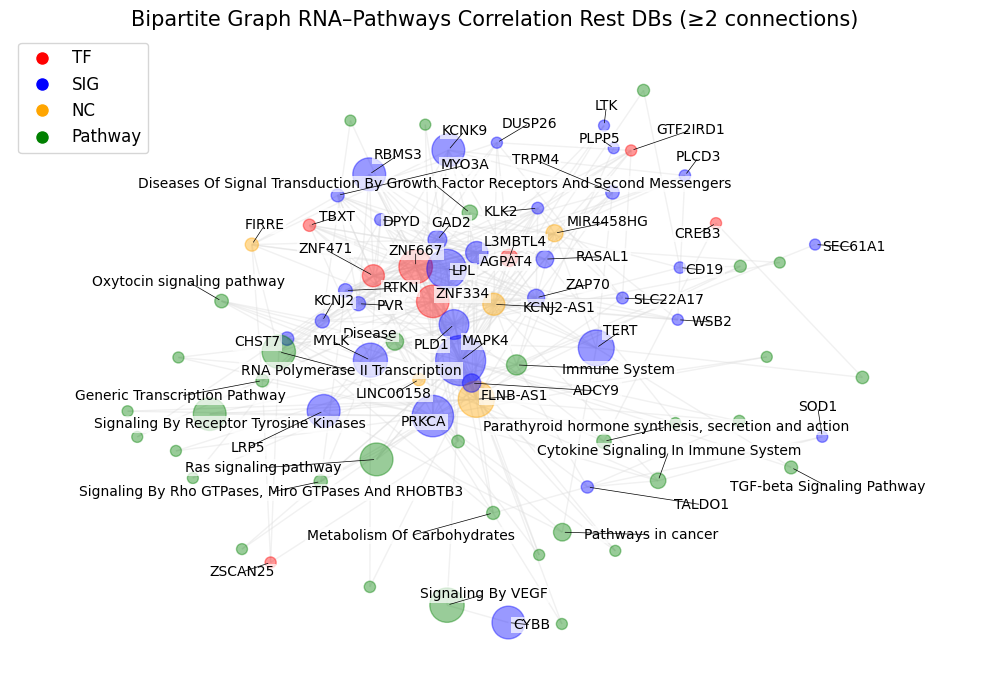

In [24]:
import re
import networkx as nx
import matplotlib.pyplot as plt
from adjustText import adjust_text

# --- PARAMETERS ---
F = G  # assuming G is already defined elsewhere

label_types = {'NC', 'TF', 'SIG'}
top_n_pathways = 15       # number of top pathways to label
min_degree_pathway = 2    # keep only pathways with ≥ 2 connections

# --- CLEAN LABELS FUNCTION ---
def clean_label(label):
    """Remove redundant IDs or GO codes from node labels."""
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# --- FILTER PATHWAYS BY DEGREE ---
pathways_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] == 'Pathway' and F.degree(n) >= min_degree_pathway
]

# --- CREATE FILTERED SUBGRAPH ---
nodes_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] in label_types or n in pathways_to_keep
]
F_filtered = F.subgraph(nodes_to_keep).copy()

# --- RECOMPUTE CENTRALITY ---
centrality = nx.betweenness_centrality(F_filtered, k=10, endpoints=True)

# --- COMPUTE PATHWAY CORRELATION (CENTRALITY AS PROXY) ---
pathway_corr = {n: centrality[n] for n in F_filtered.nodes() if F_filtered.nodes[n]['Type'] == 'Pathway'}

# --- SELECT TOP N PATHWAYS ---
top_pathways = sorted(pathway_corr, key=pathway_corr.get, reverse=True)[:top_n_pathways]

# --- CREATE LABEL DICTIONARY ---
cleaned_labels = {}
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in label_types or node in top_pathways:
        cleaned_labels[node] = clean_label(node)

# --- LAYOUT, COLORS, AND SIZES ---
pos = nx.spring_layout(F_filtered, k=0.8, seed=1400)
type_color_map = {'TF': 'red', 'SIG': 'blue', 'NC': 'orange', 'Pathway': 'green'}
node_color = [type_color_map.get(F_filtered.nodes[node]['Type'], 'grey') for node in F_filtered.nodes()]
node_size = [centrality[v] * 5000 for v in F_filtered.nodes()]

# --- PLOT ---
fig, ax = plt.subplots(figsize=(10, 7))

nx.draw_networkx_nodes(F_filtered, pos=pos, node_color=node_color, node_size=node_size, alpha=0.4)
nx.draw_networkx_edges(F_filtered, pos=pos, edge_color="gainsboro", alpha=0.4)

# --- ADD LABELS (NON-BOLD, READABLE) ---
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    text = ax.text(
        x, y, label,
        fontsize=10, color='black',
        ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1)
    )
    texts.append(text)

# Adjust label positions to minimize overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
    expand_points=(1.3, 1.3),
    force_points=0.5,
    force_text=0.5
)

# --- LEGEND ---
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
           for color in type_color_map.values()]
labels = list(type_color_map.keys())
ax.legend(handles=handles, labels=labels, loc='upper left', fontsize=12)

# --- TITLE & SAVE ---
plt.title("Bipartite Graph RNA–Pathways Correlation Rest DBs (≥2 connections)", fontsize=15)
ax.margins(0.1, 0.05)
fig.tight_layout()
plt.axis("off")
plt.savefig("../../figures/Bipartite_graph_CLL_filtered_REST.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
## all graph

In [25]:
# Step 1: Read the DataFrame with the edge connections
df_edges = combined_df_net

# Step 2: Read the DataFrame with node attributes
df_node_attributes = node_combined

#df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) | df_edges['target'].isin(df_node_attributes['ID'])]
df_edges = df_edges[df_edges['source'].isin(df_node_attributes['ID']) & df_edges['target'].isin(df_node_attributes['ID'])]

# Step 3: Create a undirected graph
G = nx.Graph()

# Step 4: Add edges to the graph
for index, row in df_edges.iterrows():
    source = row['source']
    target = row['target']
    attributes = row.drop(['source', 'target'])  # Extract edge attributes
    G.add_edge(source, target, **attributes)  # Add edge with attributes

# Step 5: Transfer node attributes
for index, row in df_node_attributes.iterrows():
    node_name = row['ID']
    if node_name in G.nodes:
        attributes = row.drop('ID')  # Remove the node name to keep only the attributes
        G.nodes[node_name].update(attributes)

# Add a new attribute 'label' with node names
for node in G.nodes:
    G.nodes[node]['label'] = str(node)  # Set 'label' attribute to node name (convert to string if needed)

print(f"Edges: {len(G.edges)}")
print(f"Nodes: {len(G.nodes)}")

NameError: name 'combined_df_net' is not defined

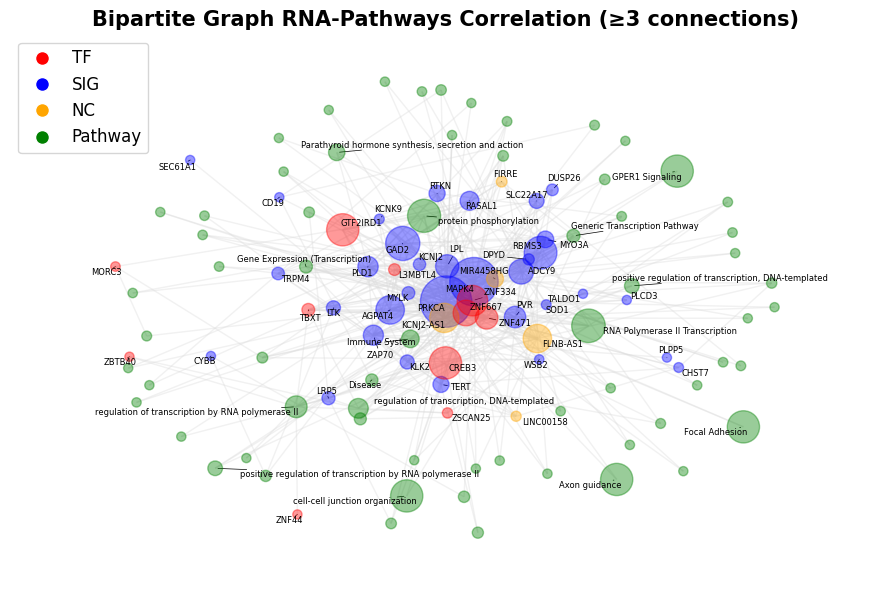

In [24]:
import networkx as nx
import matplotlib.pyplot as plt
import re
from adjustText import adjust_text

F = G

# Parameters
label_types = {'NC', 'TF', 'SIG'}
top_n_pathways = 15   # number of top pathways to label
min_degree_pathway = 2  # keep only pathways with >= 3 connections

# Clean labels function
def clean_label(label):
    patterns = [r'R-HSA-\d+', r'WP\d+', r'\(GO:\d+\)']
    for pattern in patterns:
        label = re.sub(pattern, '', label)
    return label.strip()

# Keep only pathways with at least min_degree_pathway neighbors
pathways_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] == 'Pathway' and F.degree(n) >= min_degree_pathway
]

# Create subgraph with those pathways + all other node types
nodes_to_keep = [
    n for n in F.nodes()
    if F.nodes[n]['Type'] in label_types or n in pathways_to_keep
]
F_filtered = F.subgraph(nodes_to_keep).copy()

# Recompute centrality on filtered graph
centrality = nx.betweenness_centrality(F_filtered, k=10, endpoints=True)

# Compute pathway correlation (using centrality as proxy)
pathway_corr = {n: centrality[n] for n in F_filtered.nodes() if F_filtered.nodes[n]['Type'] == 'Pathway'}

# Select top N pathways
top_pathways = sorted(pathway_corr, key=pathway_corr.get, reverse=True)[:top_n_pathways]

# Create label dictionary: NC, TF, SIG + top pathways
cleaned_labels = {}
for node in F_filtered.nodes():
    if F_filtered.nodes[node]['Type'] in label_types or node in top_pathways:
        cleaned_labels[node] = clean_label(node)

# Compute positions, colors, and node sizes
pos = nx.spring_layout(F_filtered, k=0.8, seed=1400)
type_color_map = {'TF': 'red', 'SIG': 'blue', 'NC': 'orange', 'Pathway': 'green'}
node_color = [type_color_map.get(F_filtered.nodes[node]['Type'], 'grey') for node in F_filtered.nodes()]
node_size = [centrality[v] * 5000 for v in F_filtered.nodes()]

# Plot graph
fig, ax = plt.subplots(figsize=(9, 6))

nx.draw_networkx_nodes(F_filtered, pos=pos, node_color=node_color, node_size=node_size, alpha=0.4)
nx.draw_networkx_edges(F_filtered, pos=pos, edge_color="gainsboro", alpha=0.4)

# Add labels
texts = []
for node, label in cleaned_labels.items():
    x, y = pos[node]
    text = ax.text(x, y, label, fontsize=6, ha='center', va='center')
    texts.append(text)

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10)
           for color in type_color_map.values()]
labels = list(type_color_map.keys())
ax.legend(handles=handles, labels=labels, loc='upper left', fontsize=12)

plt.title("Bipartite Graph RNA-Pathways Correlation (≥3 connections)", fontsize=15, fontweight='bold')
ax.margins(0.1, 0.05)
fig.tight_layout()
plt.axis("off")
plt.savefig("../../figures/Bipartite_graph_CLL_filtered.png", dpi=300, bbox_inches='tight')
plt.show()
